In [24]:
# Базовые библиотеки для воспроизводимости, анализа и визуализации.
import random
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import Dataset, DatasetDict
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)
pd.set_option("display.precision", 4)

In [25]:
# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [55]:
torch.version.__version__

'2.10.0+cpu'

In [26]:
df = pd.read_csv("Emotion_classify_Data.csv")
df.head()

,Comment,Emotion
0,i seriously hate one subject to death but now i feel reluctant to drop it,fear
1,im so full of life i feel appalled,anger
2,i sit here to write i start to dig out my feelings and i think that i am afraid to accept the possibility that he might not make it,fear
3,ive been really angry with r and i feel like an idiot for trusting him in the first place,joy
4,i feel suspicious if there is no one outside like the rapture has happened or something,fear


In [27]:
print("Размер датасета:", len(df))
display(df["Emotion"].value_counts())

label_names = sorted(df["Emotion"].unique())
label2id = {label: idx for idx, label in enumerate(label_names)}
id2label = {idx: label for label, idx in label2id.items()}

df["label_id"] = df["Emotion"].map(label2id)

print("label2id:", label2id)
print("id2label:", id2label)

display(df.sample(6, random_state=42).reset_index(drop=True))

Размер датасета: 5937


,count
Emotion,
anger,2000
joy,2000
fear,1937


label2id: {'anger': 0, 'fear': 1, 'joy': 2}
id2label: {0: 'anger', 1: 'fear', 2: 'joy'}


,Comment,Emotion,label_id
0,i do give up at times when i feel there s no point in a friendship when one cant be bothered,anger,0
1,im a firm believer that nothing makes a woman feel much more terrific than a great trip to the salon to lift her spirits a bit,joy,2
2,i was feeling very vulnerable and down no one really close to me has ever died before i either hadnt known them very well or was too you...,fear,1
3,i closed her eyes in anger and feeling disgusted by this touch,anger,0
4,i feel like being distracted,anger,0
5,i just feel shy because i was just a sharia stream student who is now still struggling with european union policy and decision making th...,fear,1


In [28]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label_id"],
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.25,
    random_state=42,
    stratify=train_df["label_id"],
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nРаспределение классов в train:")
display(train_df["Emotion"].value_counts())

print("Распределение классов в validation:")
display(val_df["Emotion"].value_counts())

print("Распределение классов в test:")
display(test_df["Emotion"].value_counts())

Train: (3561, 3)
Validation: (1188, 3)
Test: (1188, 3)

Распределение классов в train:


,count
Emotion,
joy,1200
anger,1200
fear,1161


Распределение классов в validation:


,count
Emotion,
joy,400
anger,400
fear,388


Распределение классов в test:


,count
Emotion,
joy,400
anger,400
fear,388


In [29]:
# Приводим датафреймы к формату HuggingFace Dataset.
train_ds = Dataset.from_pandas(
    train_df[["Comment", "label_id"]].rename(columns={"label_id": "labels"}).reset_index(drop=True),
    preserve_index=False,
)
val_ds = Dataset.from_pandas(
    val_df[["Comment", "label_id"]].rename(columns={"label_id": "labels"}).reset_index(drop=True),
    preserve_index=False,
)
test_ds = Dataset.from_pandas(
    test_df[["Comment", "label_id"]].rename(columns={"label_id": "labels"}).reset_index(drop=True),
    preserve_index=False,
)

dataset_dict = DatasetDict({
    "train": train_ds,
    "validation": val_ds,
    "test": test_ds,
})

dataset_dict

DatasetDict({
    train: Dataset({
        features: ['Comment', 'labels'],
        num_rows: 3561
    })
    validation: Dataset({
        features: ['Comment', 'labels'],
        num_rows: 1188
    })
    test: Dataset({
        features: ['Comment', 'labels'],
        num_rows: 1188
    })
})

In [30]:
# Посмотрим на несколько примеров.
print("Пример из train:")
display(dataset_dict["train"][:3])

print("Пример из validation:")
display(dataset_dict["validation"][:3])

Пример из train:


{'Comment': ['i have a sense of both in my mind s eye i feel that divine energy way up aloft and i experience its reflection in me sometimes like a rare sunny day in a rainy climate',
  'i hurt your feelings or angered you with my last rant im sorry',
  'i have a heart to serve to better their situation but in that moment i feel so helpless'],
 'labels': [2, 0, 1]}

Пример из validation:


{'Comment': ['i did wake up this morning feeling more like myself so after days of sloth i was keen to get geared up and head to higher altitudes',
  'i even had a deep feeling for alaska and the cold and snowy and yet big open land with the pine trees and mountains but im destined to live in southern california',
  'i feel that i ve been very gracious in not freaking out about finances so if you saw it fit to smooth things over monetarily i wouldn t say no'],
 'labels': [2, 0, 2]}

### В рамках данного подмножества датасета мы классифицируем три базовых типа эмоциональных состояний:

* Anger (Гнев): Выражение агрессии, раздражения или сильного недовольства.

* Joy (Радость): Проявление позитивного настроя, счастья, успеха или оптимизма.

* Fear (Страх): Ощущение тревоги, неуверенности, угрозы или паники.

In [31]:
# Компактная русскоязычная BERT-подобная модель.
MODEL_NAME = "cointegrated/rubert-tiny2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded:", tokenizer.__class__.__name__)
print("Model checkpoint:", MODEL_NAME)

def tokenize_batch(batch: Dict[str, List[str]]) -> Dict[str, List[List[int]]]:
    return tokenizer(
        batch["Comment"],
        truncation=True,
        max_length=128,
    )

tokenized_datasets = dataset_dict.map(tokenize_batch, batched=True)

# Удаляем столбец "text": DataCollatorWithPadding попытается преобразовать
# все поля датасета в тензоры, а строки в тензор не конвертируются.
tokenized_datasets = tokenized_datasets.remove_columns(["Comment"])
tokenized_datasets

Tokenizer loaded: BertTokenizer
Model checkpoint: cointegrated/rubert-tiny2


Map:   0%|          | 0/3561 [00:00<?, ? examples/s]

Map:   0%|          | 0/1188 [00:00<?, ? examples/s]

Map:   0%|          | 0/1188 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3561
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1188
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1188
    })
})

In [32]:
# Выбираем 3 примера с разной длиной для наглядности
for i in range(3):
    # Берем данные из токенизированного набора и исходный текст
    example = tokenized_datasets["train"][i]
    raw_text = dataset_dict["train"][i]["Comment"]

    print(f"{'='*20} РАЗБОР ПРИМЕРА №{i+1} {'='*20}")
    print(f"ИСХОДНЫЙ ТЕКСТ: {raw_text}")

    # 1. ТОКЕНЫ (превращаем ID обратно в слова/субслова)
    tokens = tokenizer.convert_ids_to_tokens(example["input_ids"])
    print(f"\n1. ТОКЕНЫ: {tokens[:15]}...")

    # 2. INPUT_IDS (числовые индексы в словаре)
    print(f"2. INPUT_IDS: {example['input_ids'][:15]}...")

    # 3. ATTENTION_MASK (показывает модели, куда смотреть)
    print(f"3. ATTENTION_MASK: {example['attention_mask'][:15]}...")

    # 4. SPECIAL TOKENS (показываем конкретные ID)
    print(f"4. SPECIAL TOKENS:")
    print(f"   - [CLS] (начало): {tokenizer.cls_token_id}")
    print(f"   - [SEP] (конец текста): {tokenizer.sep_token_id}")
    print(f"   - [PAD] (заполнитель): {tokenizer.pad_token_id}")

    # 5. ДЕМОНСТРАЦИЯ PADDING / TRUNCATION
    actual_len = len(tokenizer.encode(raw_text))
    print(f"\n5. МЕХАНИЗМЫ ОБРАБОТКИ:")
    print(f"   - Длина текста без дополнения: {actual_len} токенов")

    pad_count = example["input_ids"].count(tokenizer.pad_token_id)
    if pad_count > 0:
        print(f"   - PADDING: Добавлено {pad_count} токенов [PAD] до размера 128.")

    if actual_len > 128:
        print(f"   - TRUNCATION: Текст был обрезан до 128 токенов.")
    else:
        print(f"   - TRUNCATION: Не потребовался (текст короче 128).")

    print("\n" + "-"*60 + "\n")

==================== РАЗБОР ПРИМЕРА №1 ====================
ИСХОДНЫЙ ТЕКСТ: i have a sense of both in my mind s eye i feel that divine energy way up aloft and i experience its reflection in me sometimes like a rare sunny day in a rainy climate

1. ТОКЕНЫ: ['[CLS]', 'i', 'have', 'a', 'sense', 'of', 'both', 'in', 'my', 'mind', 's', 'eye', 'i', 'feel', 'that']...
2. INPUT_IDS: [2, 76, 880, 68, 3670, 534, 1456, 532, 3495, 6231, 86, 10464, 76, 12235, 611]...
3. ATTENTION_MASK: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]...
4. SPECIAL TOKENS:
   - [CLS] (начало): 2
   - [SEP] (конец текста): 3
   - [PAD] (заполнитель): 0

5. МЕХАНИЗМЫ ОБРАБОТКИ:
   - Длина текста без дополнения: 42 токенов
   - TRUNCATION: Не потребовался (текст короче 128).

------------------------------------------------------------

==================== РАЗБОР ПРИМЕРА №2 ====================
ИСХОДНЫЙ ТЕКСТ: i hurt your feelings or angered you with my last rant im sorry

1. ТОКЕНЫ: ['[CLS]', 'i', 'hur', '##t', 'your', '

In [33]:
# Data collator будет добавлять padding динамически, прямо при формировании батча.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

sample_batch = [tokenized_datasets["train"][i] for i in range(3)]
collated_batch = data_collator(sample_batch)

for key, value in collated_batch.items():
    print(f"{key}: shape={tuple(value.shape)}")

labels: shape=(3,)
input_ids: shape=(3, 42)
token_type_ids: shape=(3, 42)
attention_mask: shape=(3, 42)


In [34]:
# Загружаем модель для классификации.
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

model.to(device)

print("Model class:", model.__class__.__name__)
print("Number of labels:", model.config.num_labels)
print("id2label:", model.config.id2label)

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider trai

Model class: BertForSequenceClassification
Number of labels: 3
id2label: {0: 'anger', 1: 'fear', 2: 'joy'}


In [35]:

# Функция метрик для Trainer.
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }

In [36]:
# Общие параметры обучения.
common_training_kwargs = dict(
    output_dir="outputs/s13_bert_finetuning_demo",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=2,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
)

try:
    training_args = TrainingArguments(
        evaluation_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )
except TypeError:
    training_args = TrainingArguments(
        eval_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )

training_args

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

In [37]:
# Собираем Trainer и запускаем обучение.
# В transformers >= 5.0 аргумент tokenizer переименован в processing_class.
try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

train_result = trainer.train()
train_result

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.490587,0.664419,0.803030,0.803112,0.803250
2,0.143068,0.337278,0.883838,0.884086,0.884131
3,0.262714,0.266430,0.908249,0.908428,0.908443
4,0.234956,0.259673,0.909091,0.909256,0.909246
5,0.027130,0.257385,0.910774,0.910919,0.910932


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.beta', 'bert.embeddings.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.

TrainOutput(global_step=2230, training_loss=0.4260418328135003, metrics={'train_runtime': 880.4673, 'train_samples_per_second': 20.222, 'train_steps_per_second': 2.533, 'total_flos': 11771791673598.0, 'train_loss': 0.4260418328135003, 'epoch': 5.0})

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_f1_macro,eval_f1_weighted,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.1076,1.1365,1.9991e-05,0.0045,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0908,1.6867,1.9973e-05,0.0090,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0988,1.3530,1.9955e-05,0.0135,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0898,1.4671,1.9937e-05,0.0179,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.1031,1.2179,1.9919e-05,0.0224,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1.0852,1.0909,1.9901e-05,0.0269,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1.1112,1.1871,1.9883e-05,0.0314,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1.0895,1.2794,1.9865e-05,0.0359,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1.0994,2.2478,1.9848e-05,0.0404,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1.1074,1.1825,1.9830e-05,0.0448,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


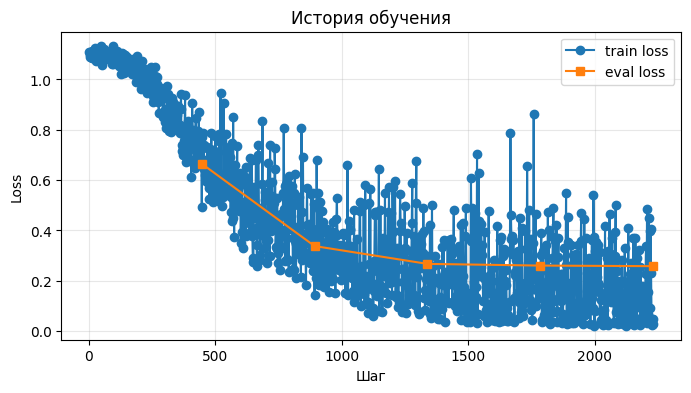

In [38]:
# История логов Trainer.
history_df = pd.DataFrame(trainer.state.log_history)
display(history_df.head(10))

plt.figure(figsize=(8, 4))

if "loss" in history_df.columns:
    train_logs = history_df.dropna(subset=["loss"])
    plt.plot(train_logs["step"], train_logs["loss"], marker="o", label="train loss")

if "eval_loss" in history_df.columns:
    eval_logs = history_df.dropna(subset=["eval_loss"])
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], marker="s", label="eval loss")

plt.title("История обучения")
plt.xlabel("Шаг")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [39]:

# В transformers >= 5.x NotebookProgressCallback теряет состояние после обучения,
# что вызывает RuntimeError при вызове evaluate() вне тренировочного цикла.
# Удаляем его перед standalone-оценкой – это стандартный обходной путь.
from transformers.utils.notebook import NotebookProgressCallback
trainer.remove_callback(NotebookProgressCallback)

# Оценка Trainer на validation и test.
val_metrics = trainer.evaluate(tokenized_datasets["validation"])
test_metrics = trainer.evaluate(tokenized_datasets["test"])

print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

print("\nTest metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation metrics:
eval_loss: 0.2574
eval_accuracy: 0.9108
eval_f1_macro: 0.9109
eval_f1_weighted: 0.9109
eval_runtime: 6.5514
eval_samples_per_second: 181.3350
eval_steps_per_second: 22.7430
epoch: 5.0000

Test metrics:
eval_loss: 0.2630
eval_accuracy: 0.9158
eval_f1_macro: 0.9158
eval_f1_weighted: 0.9159
eval_runtime: 7.7576
eval_samples_per_second: 153.1410
eval_steps_per_second: 19.2070
epoch: 5.0000


In [52]:
import os
from pathlib import Path

ARTIFACT_PATH = Path('artifacts')
os.makedirs(ARTIFACT_PATH, exist_ok=True)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation metrics:
eval_loss: 0.2574
eval_accuracy: 0.9108
eval_f1_macro: 0.9109
eval_f1_weighted: 0.9109
eval_runtime: 13.4149
eval_samples_per_second: 88.5580
eval_steps_per_second: 11.1070
epoch: 5.0000

Test metrics:
eval_loss: 0.2630
eval_accuracy: 0.9158
eval_f1_macro: 0.9158
eval_f1_weighted: 0.9159
eval_runtime: 15.2882
eval_samples_per_second: 77.7070
eval_steps_per_second: 9.7460
epoch: 5.0000


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Classification report on test:
              precision    recall  f1-score   support

       anger       0.92      0.92      0.92       400
        fear       0.89      0.93      0.91       388
         joy       0.94      0.90      0.92       400

    accuracy                           0.92      1188
   macro avg       0.92      0.92      0.92      1188
weighted avg       0.92      0.92      0.92      1188



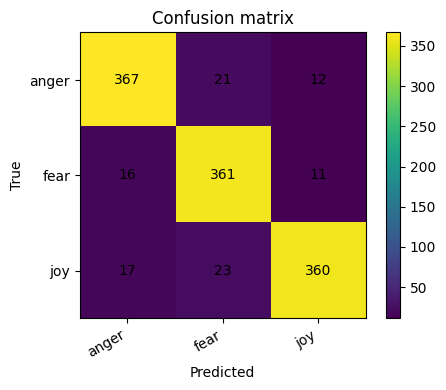

In [53]:
# В transformers >= 5.x NotebookProgressCallback теряет состояние после обучения,
# что вызывает RuntimeError при вызове evaluate() вне тренировочного цикла.
# Удаляем его перед standalone-оценкой – это стандартный обходной путь.
from transformers.utils.notebook import NotebookProgressCallback
trainer.remove_callback(NotebookProgressCallback)

# Оценка Trainer на validation и test.
val_metrics = trainer.evaluate(tokenized_datasets["validation"])
test_metrics = trainer.evaluate(tokenized_datasets["test"])

print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

print("\nTest metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")
# Детальные предсказания на тестовой выборке.
test_output = trainer.predict(tokenized_datasets["test"])
test_logits = test_output.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_true = test_output.label_ids

print("Classification report on test:")
print(
    classification_report(
        test_true,
        test_preds,
        target_names=[id2label[i] for i in range(len(id2label))],
        zero_division=0,
    )
)

cm = confusion_matrix(test_true, test_preds)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)

ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=30, ha="right")
ax.set_yticklabels(label_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.tight_layout()
path = ARTIFACT_PATH / "confusion_matrix.png"
plt.savefig(path)
plt.show()

In [46]:
import numpy as np

# 1. Получаем предсказания (если еще не сделали)
test_results = trainer.predict(tokenized_datasets["test"])
predictions = np.argmax(test_results.predictions, axis=-1)
labels = test_results.label_ids

# 2. Выводим 10 примеров
print(f"{'№':<3} | {'Результат':<10} | {'Текст (восстановлен из токенов)'}")
print("-" * 110)

for i in range(10):
    # Декодируем input_ids обратно в читаемый текст
    # skip_special_tokens=True уберет технические токены [CLS], [SEP], [PAD]
    decoded_text = tokenizer.decode(tokenized_datasets["test"][i]["input_ids"], skip_special_tokens=True)

    # Обрезаем для компактности
    display_text = (decoded_text[:85] + '..') if len(decoded_text) > 85 else decoded_text

    true_idx = labels[i]
    pred_idx = predictions[i]

    # Определяем статус
    status = "✅ OK" if true_idx == pred_idx else "❌ FAIL"

    # Получаем названия классов из конфигурации модели
    true_label = model.config.id2label[true_idx]
    pred_label = model.config.id2label[pred_idx]

    print(f"{i+1:<3} | {status:<10} | {display_text}")
    print(f"    └─ Реальный: {true_label} | Предсказано: {pred_label}\n")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


№   | Результат  | Текст (восстановлен из токенов)
--------------------------------------------------------------------------------------------------------------
1   | ❌ FAIL     | i became more dismayed as i studied what people were wearing and started feeling like..
    └─ Реальный: joy | Предсказано: anger

2   | ✅ OK       | im sure ill also feel a bit nervous
    └─ Реальный: fear | Предсказано: fear

3   | ✅ OK       | i was made to feel like it was my fault that i couldn t control my husband and his vi..
    └─ Реальный: anger | Предсказано: anger

4   | ✅ OK       | i feel like i could have gotten all apprehensive for no reason at all
    └─ Реальный: fear | Предсказано: fear

5   | ✅ OK       | i hate feeling pressured into having to carry on conversations because if i didnt it ..
    └─ Реальный: fear | Предсказано: fear

6   | ✅ OK       | i really can carry a grudge for a long time against those i feel have wronged or hurt..
    └─ Реальный: anger | Предсказано: anger

7   

Здесь мы видим классический «шум» в данных или очень тонкий контекст:

Почему модель выбрала anger (или fear): Слово «dismayed» (встревоженный, разочарованный) само по себе имеет негативную окраску. Модель сочла это проявлением агрессии или раздражения.

Почему в разметке joy? Это выглядит как ошибка разметки (label noise) в исходном датасете. Трудно представить ситуацию, где чувство тревоги и разочарования от одежды окружающих классифицируется как «радость».

Вывод: Модель здесь, возможно, «умнее» разметчика или датасет содержит сарказм, который не понятен без полного текста

In [54]:
import pandas as pd

# 1. Выбираем первые 10 индексов (как в нашем выводе)
indices = range(10)

sample_data = []

for i in indices:
    # Декодируем текст из input_ids (без спецтокенов)
    text = tokenizer.decode(tokenized_datasets["test"][i]["input_ids"], skip_special_tokens=True)

    # Получаем ID меток из результатов предикта
    true_idx = labels[i]
    pred_idx = predictions[i]

    # Переводим ID в текстовые названия (joy, anger, fear и т.д.)
    true_label_name = model.config.id2label[true_idx]
    pred_label_name = model.config.id2label[pred_idx]

    sample_data.append({
        "text": text,
        "true_label": true_label_name,
        "pred_label": pred_label_name,
        "is_correct": true_idx == pred_idx
    })

# 2. Создаем DataFrame и сохраняем
df_10_samples = pd.DataFrame(sample_data)
df_10_samples.to_csv(ARTIFACT_PATH/"sample_predictions.csv", index=False, encoding="utf-8")

print("Файл 'sample_predictions.csv' с 10 примерами создан!")
# Выведем превью таблицы для проверки
print(df_10_samples[['true_label', 'pred_label', 'is_correct']])

Файл 'sample_predictions.csv' с 10 примерами создан!
  true_label pred_label  is_correct
0        joy      anger       False
1       fear       fear        True
2      anger      anger        True
3       fear       fear        True
4       fear       fear        True
5      anger      anger        True
6       fear       fear        True
7      anger      anger        True
8      anger      anger        True
9      anger      anger        True
